Profiles Shape: (48, 7)
Choices Shape: (2760, 7)
  profile_id   brand_tier  price_inr   battery        camera warranty  \
0       P001      Premium      22999  5500 mAh   Dual Camera  3 years   
1       P002      Premium      34999  4500 mAh   Dual Camera  3 years   
2       P003      Premium      34999  6500 mAh  Basic Camera   1 year   
3       P004  Local Value      22999  6500 mAh    Pro Camera  2 years   
4       P005   Challenger      22999  4500 mAh   Dual Camera   1 year   

  delivery_time  
0        2 days  
1        2 days  
2        5 days  
3        2 days  
4        2 days  
  respondent_id respondent_segment income_band  choice_task  \
0          R001     Family Shopper      Medium            1   
1          R001     Family Shopper      Medium            1   
2          R001     Family Shopper      Medium            1   
3          R001     Family Shopper      Medium            2   
4          R001     Family Shopper      Medium            2   

   alternative_number pro

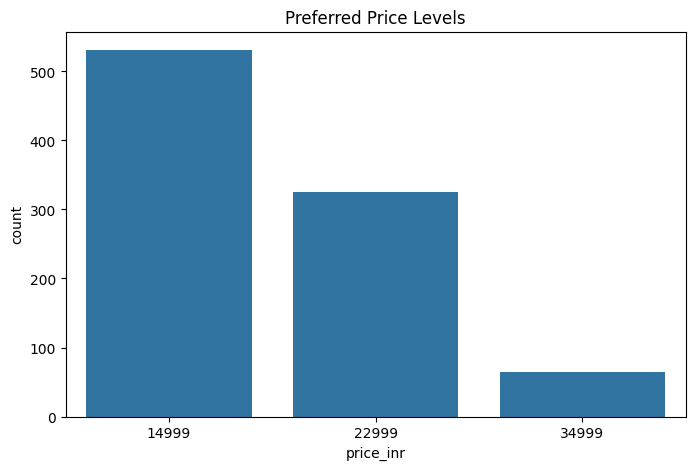

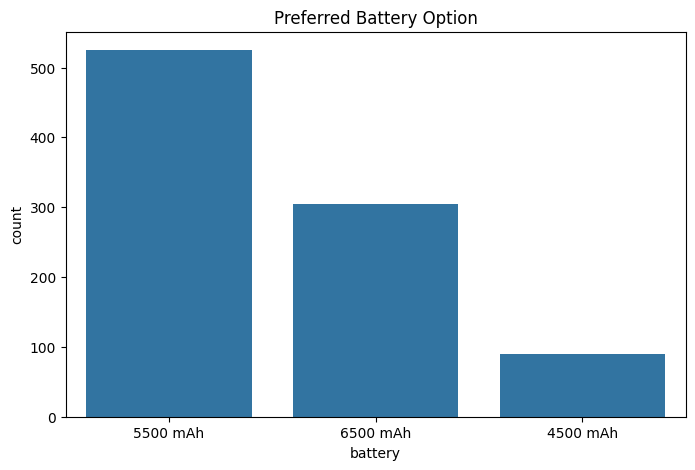

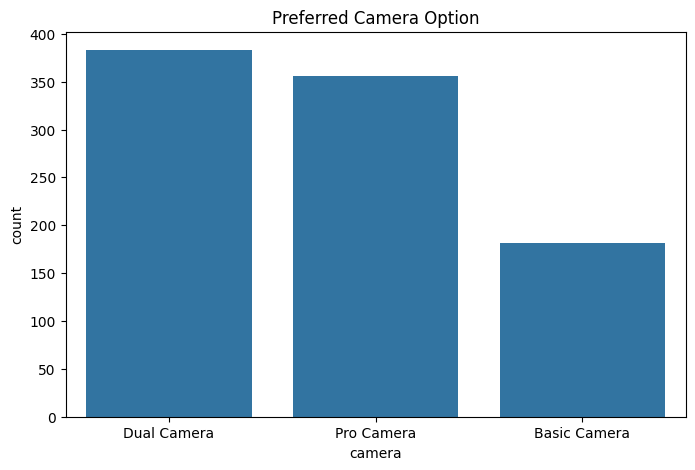

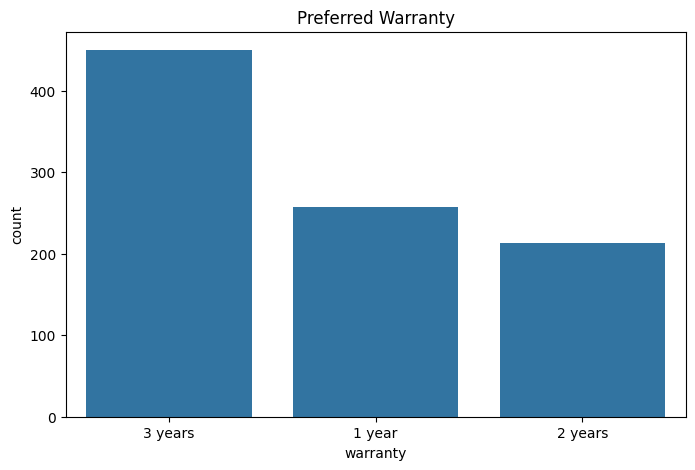

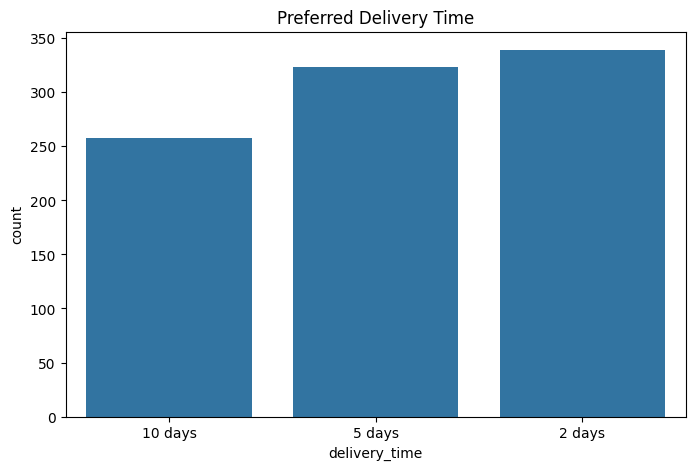


TRADE-OFF SUMMARY
  Attribute Most Preferred Option
0     Price                 14999
1   Battery              5500 mAh
2    Camera           Dual Camera
3  Warranty               3 years
4  Delivery                2 days


In [2]:
# ==========================================================
# PRODUCT CONCEPT PREFERENCE STUDY
# DATASET E
# TRADE-OFF ANALYSIS
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# LOAD DATA
# ------------------------------

profiles = pd.read_csv("E1_Product_Concept_Profiles.csv")
choices = pd.read_csv("E2_Product_Concept_Choice_Responses.csv")

print("Profiles Shape:", profiles.shape)
print("Choices Shape:", choices.shape)

print(profiles.head())
print(choices.head())

# ------------------------------
# MERGE DATASETS
# ------------------------------

df = choices.merge(
    profiles,
    on="profile_id",
    how="left"
)

print(df.shape)

# ------------------------------
# CHOSEN PRODUCTS ONLY
# ------------------------------

chosen_df = df[
    df["chosen"] == 1
]

print(chosen_df.shape)

# ==========================================================
# ATTRIBUTE PREFERENCE ANALYSIS
# ==========================================================

# PRICE

price_pref = (
    chosen_df["price_inr"]
    .value_counts(normalize=True)*100
)

print("\nPrice Preference")
print(price_pref)

# BATTERY

battery_pref = (
    chosen_df["battery"]
    .value_counts(normalize=True)*100
)

print("\nBattery Preference")
print(battery_pref)

# CAMERA

camera_pref = (
    chosen_df["camera"]
    .value_counts(normalize=True)*100
)

print("\nCamera Preference")
print(camera_pref)

# WARRANTY

warranty_pref = (
    chosen_df["warranty"]
    .value_counts(normalize=True)*100
)

print("\nWarranty Preference")
print(warranty_pref)

# DELIVERY

delivery_pref = (
    chosen_df["delivery_time"]
    .value_counts(normalize=True)*100
)

print("\nDelivery Preference")
print(delivery_pref)

# ==========================================================
# VISUALIZATION 1
# PRICE
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=chosen_df,
    x="price_inr"
)

plt.title("Preferred Price Levels")

plt.show()

# ==========================================================
# VISUALIZATION 2
# BATTERY
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=chosen_df,
    x="battery"
)

plt.title("Preferred Battery Option")

plt.show()

# ==========================================================
# VISUALIZATION 3
# CAMERA
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=chosen_df,
    x="camera"
)

plt.title("Preferred Camera Option")

plt.show()

# ==========================================================
# VISUALIZATION 4
# WARRANTY
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=chosen_df,
    x="warranty"
)

plt.title("Preferred Warranty")

plt.show()

# ==========================================================
# VISUALIZATION 5
# DELIVERY TIME
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=chosen_df,
    x="delivery_time"
)

plt.title("Preferred Delivery Time")

plt.show()

# ==========================================================
# TRADE-OFF TABLE
# ==========================================================

tradeoff = pd.DataFrame({
    "Attribute":[
        "Price",
        "Battery",
        "Camera",
        "Warranty",
        "Delivery"
    ],
    "Most Preferred Option":[
        price_pref.idxmax(),
        battery_pref.idxmax(),
        camera_pref.idxmax(),
        warranty_pref.idxmax(),
        delivery_pref.idxmax()
    ]
})

print("\nTRADE-OFF SUMMARY")
print(tradeoff)

## Product Concept Preference Dashboard

### 1. Price Preference Analysis

In [3]:
print("Price Preference (%):")
display(price_pref)

Price Preference (%):


,proportion
price_inr,
14999,57.717391
22999,35.326087
34999,6.956522


/tmp/ipykernel_578/766458553.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=chosen_df, x="price_inr", palette='viridis')


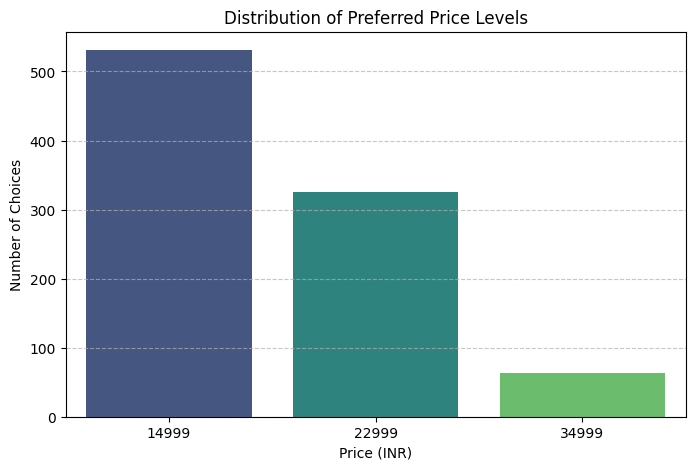

In [4]:
plt.figure(figsize=(8,5))
sns.countplot(data=chosen_df, x="price_inr", palette='viridis')
plt.title("Distribution of Preferred Price Levels")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Choices")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretation:
The lowest price point (14999 INR) is overwhelmingly preferred by customers, accounting for over 57% of choices. This indicates high price sensitivity in the market for this product concept, with significantly fewer customers opting for the higher price tiers.

### 2. Battery Preference Analysis

In [5]:
print("Battery Preference (%):")
display(battery_pref)

Battery Preference (%):


,proportion
battery,
5500 mAh,57.065217
6500 mAh,33.152174
4500 mAh,9.782609


/tmp/ipykernel_578/3858390455.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=chosen_df, x="battery", palette='mako')


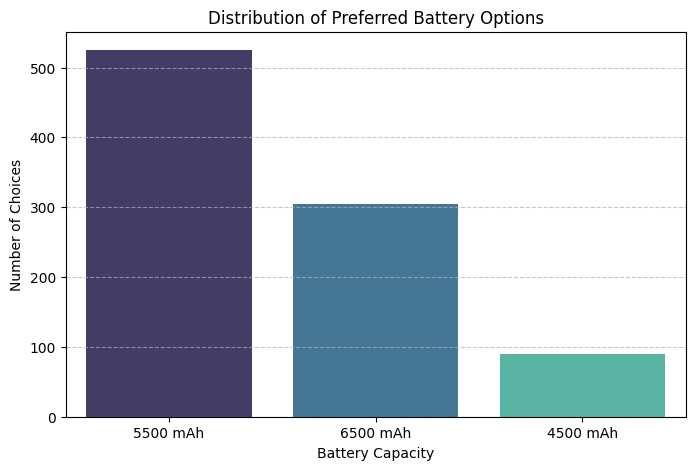

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=chosen_df, x="battery", palette='mako')
plt.title("Distribution of Preferred Battery Options")
plt.xlabel("Battery Capacity")
plt.ylabel("Number of Choices")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretation:
The 5500 mAh battery option is the most preferred, capturing over 57% of customer choices. This suggests that while a high battery capacity is valued, there might be a point of diminishing returns or an optimal balance between battery size and other product attributes, as the 6500 mAh option is less popular than the 5500 mAh.

### 3. Camera Preference Analysis

In [7]:
print("Camera Preference (%):")
display(camera_pref)

Camera Preference (%):


,proportion
camera,
Dual Camera,41.630435
Pro Camera,38.695652
Basic Camera,19.673913


/tmp/ipykernel_578/3250980568.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=chosen_df, x="camera", palette='flare')


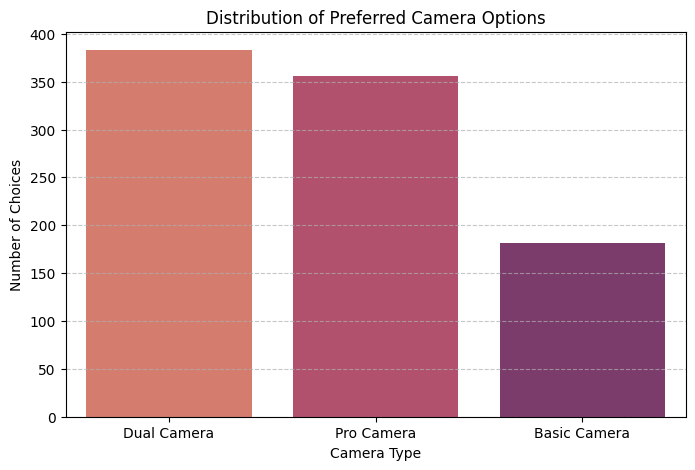

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(data=chosen_df, x="camera", palette='flare')
plt.title("Distribution of Preferred Camera Options")
plt.xlabel("Camera Type")
plt.ylabel("Number of Choices")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretation:
Dual Camera and Pro Camera options are nearly equally preferred, with Dual Camera having a slight edge at over 41%. The Basic Camera option is significantly less desired, indicating that customers value enhanced camera features. The close preference between Dual and Pro cameras suggests that both are highly appealing, potentially catering to slightly different user segments.

### 4. Warranty Preference Analysis

In [9]:
print("Warranty Preference (%):")
display(warranty_pref)

Warranty Preference (%):


,proportion
warranty,
3 years,48.913043
1 year,27.934783
2 years,23.152174


/tmp/ipykernel_578/4135513339.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=chosen_df, x="warranty", palette='crest')


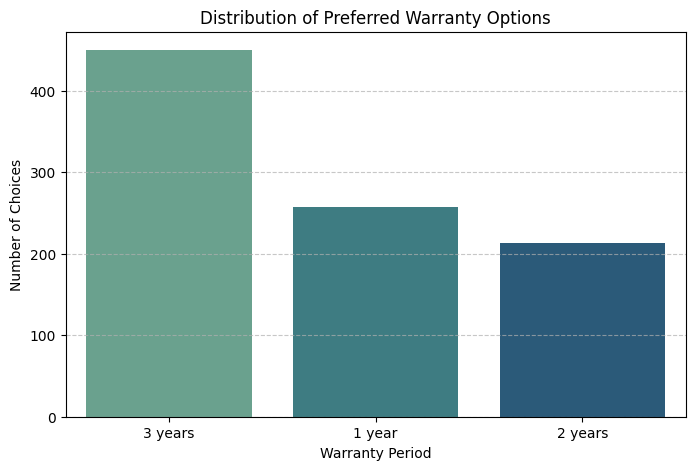

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=chosen_df, x="warranty", palette='crest')
plt.title("Distribution of Preferred Warranty Options")
plt.xlabel("Warranty Period")
plt.ylabel("Number of Choices")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretation:
A 3-year warranty is the most preferred option, chosen by almost 49% of customers. This highlights the importance of extended product protection for consumers, indicating that a longer warranty period can be a significant differentiator and trust builder.

### 5. Delivery Time Preference Analysis

In [11]:
print("Delivery Preference (%):")
display(delivery_pref)

Delivery Preference (%):


,proportion
delivery_time,
2 days,36.847826
5 days,35.108696
10 days,28.043478


/tmp/ipykernel_578/1414068640.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=chosen_df, x="delivery_time", palette='rocket')


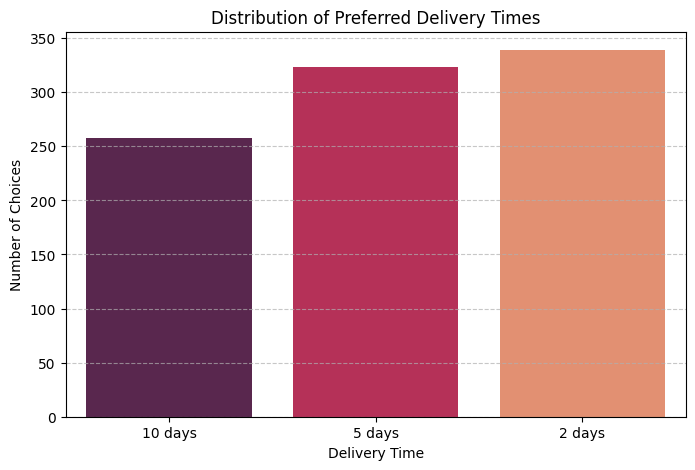

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=chosen_df, x="delivery_time", palette='rocket')
plt.title("Distribution of Preferred Delivery Times")
plt.xlabel("Delivery Time")
plt.ylabel("Number of Choices")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Interpretation:
Faster delivery options (2 days and 5 days) are preferred over the 10-day delivery, with 2 days being marginally more popular. This suggests that while speed is important, there might be a degree of flexibility, and a 5-day delivery is also quite acceptable if other attributes are compelling. Very long delivery times are generally undesirable.

### 6. Overall Trade-Off Summary

In [13]:
print("Trade-Off Summary:")
display(tradeoff)

Trade-Off Summary:


,Attribute,Most Preferred Option
0,Price,14999
1,Battery,5500 mAh
2,Camera,Dual Camera
3,Warranty,3 years
4,Delivery,2 days


#### Interpretation:
This table summarizes the most preferred option for each attribute based on customer choices. Customers show a strong preference for lower prices (14999 INR), a good balance in battery capacity (5500 mAh), advanced camera features (Dual Camera), extended warranty (3 years), and faster delivery (2 days). These insights are crucial for product development and marketing strategies, highlighting the key features that drive customer preference in this product category.

## Combined Product Concept Preferences

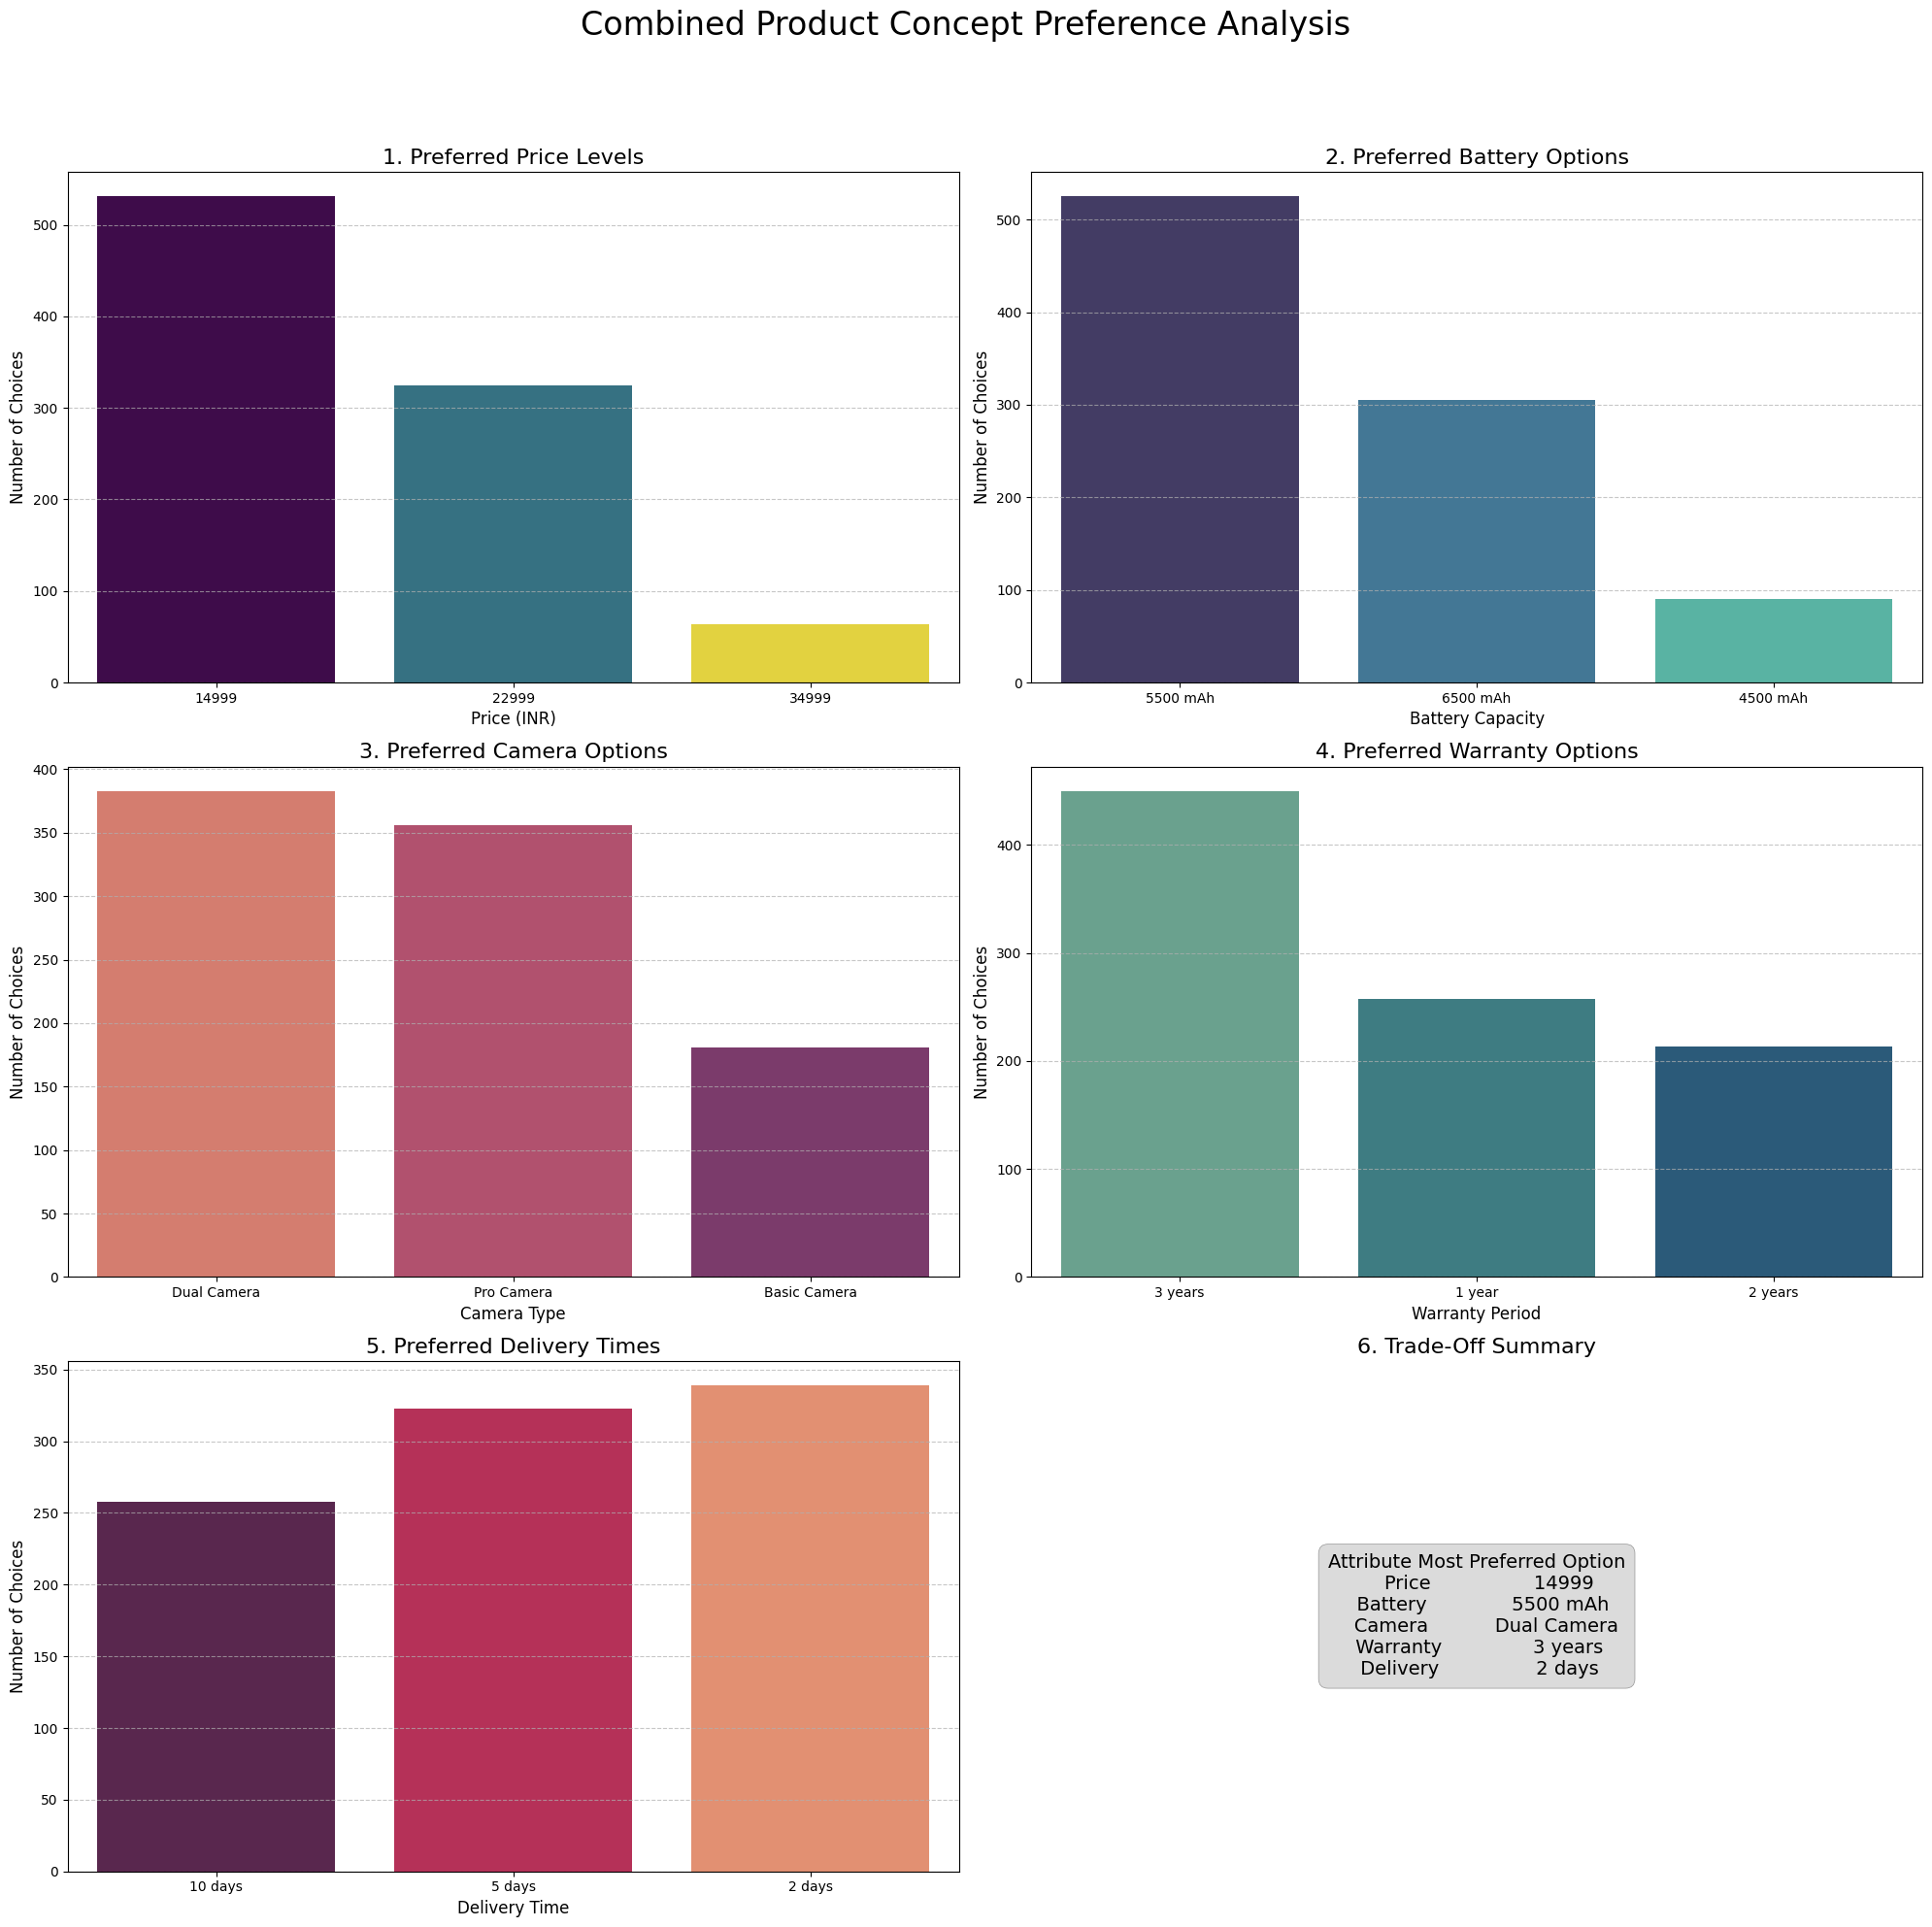

In [17]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 20))
fig.suptitle('Combined Product Concept Preference Analysis', fontsize=24, y=1.02)

# Price Preference
sns.countplot(ax=axes[0, 0], data=chosen_df, x="price_inr", hue="price_inr", palette='viridis', legend=False)
axes[0, 0].set_title("1. Preferred Price Levels", fontsize=16)
axes[0, 0].set_xlabel("Price (INR)", fontsize=12)
axes[0, 0].set_ylabel("Number of Choices", fontsize=12)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Battery Preference
sns.countplot(ax=axes[0, 1], data=chosen_df, x="battery", hue="battery", palette='mako', legend=False)
axes[0, 1].set_title("2. Preferred Battery Options", fontsize=16)
axes[0, 1].set_xlabel("Battery Capacity", fontsize=12)
axes[0, 1].set_ylabel("Number of Choices", fontsize=12)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Camera Preference
sns.countplot(ax=axes[1, 0], data=chosen_df, x="camera", hue="camera", palette='flare', legend=False)
axes[1, 0].set_title("3. Preferred Camera Options", fontsize=16)
axes[1, 0].set_xlabel("Camera Type", fontsize=12)
axes[1, 0].set_ylabel("Number of Choices", fontsize=12)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Warranty Preference
sns.countplot(ax=axes[1, 1], data=chosen_df, x="warranty", hue="warranty", palette='crest', legend=False)
axes[1, 1].set_title("4. Preferred Warranty Options", fontsize=16)
axes[1, 1].set_xlabel("Warranty Period", fontsize=12)
axes[1, 1].set_ylabel("Number of Choices", fontsize=12)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Delivery Time Preference
sns.countplot(ax=axes[2, 0], data=chosen_df, x="delivery_time", hue="delivery_time", palette='rocket', legend=False)
axes[2, 0].set_title("5. Preferred Delivery Times", fontsize=16)
axes[2, 0].set_xlabel("Delivery Time", fontsize=12)
axes[2, 0].set_ylabel("Number of Choices", fontsize=12)
axes[2, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Trade-Off Summary in the last subplot
axes[2, 1].set_title("6. Trade-Off Summary", fontsize=16)
axes[2, 1].axis('off') # Hide axes for a cleaner table display

# Format the DataFrame for display
tradeoff_str = tradeoff.to_string(index=False)
axes[2, 1].text(0.5, 0.5, tradeoff_str, transform=axes[2, 1].transAxes,
                fontsize=14, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.5', fc='lightgray', ec='gray', lw=0.5, alpha=0.8))

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

## Trade-Off Summary

In [16]:
display(tradeoff)

,Attribute,Most Preferred Option
0,Price,14999
1,Battery,5500 mAh
2,Camera,Dual Camera
3,Warranty,3 years
4,Delivery,2 days
